# Практика 3 — CatBoost, Optuna и сохранение модели

**Модуль 03 · AI HUB**

---

## Что делаем в этой практике

Финальный шаг модуля: заменяем TF-IDF + LogReg на **CatBoost с `text_features`** — он сам строит Bag-of-Words и BM25 внутри. Добавляем мета-признаки, подбираем гиперпараметры через **Optuna** и сохраняем готовую модель.

1. Обучаем CatBoost с `text_features=['text']` и `class_weights=[1.0, 7.0]`
2. Сравниваем с лучшим результатом из Практики 2
3. Запускаем Optuna: минимум 30 триалов по `depth`, `learning_rate`, `iterations`, `l2_leaf_reg`
4. Обучаем финальную модель с лучшими параметрами
5. Сохраняем как `artifacts/spam_clf.pkl` через joblib


## Настройка окружения

Установите необходимые библиотеки:
```bash
pip install catboost optuna joblib
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install catboost optuna joblib

^C


   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 4.2 MB/s eta 0:00:24
    --------------------------------------- 2.1/100.2 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 3.1/100.2 MB 4.9 MB/s eta 0:00:21
   - -------------------------------------- 4.2/100.2 MB 5.0 MB/s eta 0:00:20
   - -------------------------------------- 5.0/100.2 MB 5.0 MB/s eta 0:00:20
   -- ------------------------------------- 5.8/100.2 MB 4.5 MB/s eta 0:00:21
   -- ------------------------------------- 6.0/100.2 MB 4.3 MB/s eta 0:00:23
   -- ------------------------------------- 6.6/100.2 MB 3.9 MB/s eta 0:00:24
   -- ------------------------------------- 7.1/100.2 MB 3.7 MB/s eta 0:00:26
   -- ------------------------------------- 7.3/100.2 MB 3.6 MB/s eta 0:00:26
   --- ------------------------------------ 7.9/100.2 MB 3.5 MB/s eta 0:00:27


In [3]:
import joblib
import numpy as np
import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("Всё импортировано успешно.")

Всё импортировано успешно.


---

## Задание 1 — Загрузка данных и сплит

**Что нужно сделать:**
1. Загрузите `SMSSpamCollection`, создайте `is_spam`, удалите пустые строки
2. Добавьте мета-признаки: `len`, `caps_ratio`, `exclaim_ratio`, `digit_ratio`
3. Сделайте train/test split: 80% / 20%, `random_state=42`, `stratify=is_spam`
4. Сохраните: `X_train`, `X_test`, `y_train`, `y_test`  
   Каждый из них — `pd.DataFrame` с колонками `text`, `len`, `caps_ratio`, `exclaim_ratio`, `digit_ratio`
5. Выведите размеры и баланс классов в train и test

In [4]:
df = pd.read_csv('data.csv', encoding='cp1251')
df = df.rename(columns={'v2': 'text'})
df['is_spam'] = (df['v1'] == 'spam').astype(int)
df = df.drop(['v1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != '']

df['len'] = df['text'].str.len()
df['caps_ratio'] = df['text'].apply(lambda s: sum(1 for ch in s if ch.isupper()) / max(1, len(s)))
df['exclaim_ratio'] = df['text'].apply(lambda s: s.count('!') / max(1, len(s)))
df['digit_ratio'] = df['text'].apply(lambda s: sum(1 for ch in s if ch.isdigit()) / max(1, len(s)))

META_COLS = ['len', 'caps_ratio', 'exclaim_ratio', 'digit_ratio']

# Формируем X как DataFrame со всеми нужными признаками (текст + мета)
X = df[['text'] + META_COLS].copy()
y = df['is_spam']

# Разделение: 80% train, 20% test, стратификация по y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Вывод размеров
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Баланс классов
print("\nБаланс классов в train:")
print(y_train.value_counts(normalize=True))
print("\nБаланс классов в test:")
print(y_test.value_counts(normalize=True))

#cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



X_train shape: (4457, 5)
X_test shape: (1115, 5)
y_train shape: (4457,)
y_test shape: (1115,)

Баланс классов в train:
is_spam
0    0.865829
1    0.134171
Name: proportion, dtype: float64

Баланс классов в test:
is_spam
0    0.866368
1    0.133632
Name: proportion, dtype: float64


---

## Задание 2 — Базовый CatBoost с `text_features`

Ключевая особенность CatBoost: он умеет принимать сырой текст через `text_features` — никакого TF-IDF вручную.

**Что нужно сделать:**
1. Создайте `CatBoostClassifier` с параметрами:
   - `iterations=3000`
   - `learning_rate=0.05`
   - `depth=6`
   - `loss_function='Logloss'`
   - `eval_metric='AUC'`
   - `class_weights=[1.0, 7.0]` — компенсация дисбаланса 87/13
   - `text_features=['text']` — CatBoost сам обработает текст
   - `early_stopping_rounds=100`
   - `verbose=200`
   - `random_seed=42`
2. Обучите: `model.fit(X_train[['text']], y_train, eval_set=(X_test[['text']], y_test))`
3. Выведите F1(spam) и ROC-AUC на test


In [5]:
# Создание модели
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1.0, 7.0],  
    text_features=['text'],
    early_stopping_rounds=100,
    verbose=200,
    random_seed=42
)

# Обучение модели на тренировочных данных
model.fit(
    X_train[['text']], 
    y_train, 
    eval_set=(X_test[['text']], y_test)
)

# Предсказание вероятностей и меток на тестовой выборке
y_pred_proba = model.predict_proba(X_test[['text']])[:, 1]  
y_pred = model.predict(X_test[['text']])                    

# Метрики
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"F1 (spam): {f1:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

0:	test: 0.9475176	best: 0.9475176 (0)	total: 166ms	remaining: 8m 17s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9897279309
bestIteration = 43

Shrink model to first 44 iterations.
F1 (spam): 0.912
ROC-AUC: 0.990


**Результат:**  
*(запишите F1(spam) и ROC-AUC на test)*

---

## Задание 3 — CatBoost с мета-признаками

Теперь добавим мета-признаки — посмотрим, дают ли они прирост над чистым текстом.

**Что нужно сделать:**
1. Обучите такую же модель, но передайте все колонки:
   ```python
   FEAT_COLS = ['text', 'len', 'caps_ratio', 'exclaim_ratio', 'digit_ratio']
   model_meta.fit(X_train[FEAT_COLS], y_train, eval_set=(X_test[FEAT_COLS], y_tst))
   ```
2. Выведите F1(spam) и ROC-AUC на test
3. Сравните с результатом из Задания 2


In [6]:
FEAT_COLS = ['text', 'len', 'caps_ratio', 'exclaim_ratio', 'digit_ratio']

model_meta = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1.0, 7.0],
    text_features=['text'],          
    early_stopping_rounds=100,
    verbose=200,
    random_seed=42
)

# Обучение на всех признаках (текст + мета)
model_meta.fit(
    X_train[FEAT_COLS], 
    y_train, 
    eval_set=(X_test[FEAT_COLS], y_test)
)

# Предсказание
y_pred_proba_meta = model_meta.predict_proba(X_test[FEAT_COLS])[:, 1]
y_pred_meta = model_meta.predict(X_test[FEAT_COLS])

# Метрики
f1_meta = f1_score(y_test, y_pred_meta, pos_label=1)
roc_auc_meta = roc_auc_score(y_test, y_pred_proba_meta)

print(f"F1 (spam) с мета-признаками: {f1_meta:.4f}")
print(f"ROC-AUC с мета-признаками: {roc_auc_meta:.4f}")


0:	test: 0.9425744	best: 0.9425744 (0)	total: 27.1ms	remaining: 1m 21s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.99629344
bestIteration = 71

Shrink model to first 72 iterations.
F1 (spam) с мета-признаками: 0.9456
ROC-AUC с мета-признаками: 0.9963


**Сравнение:**

| Модель | F1(spam) test | ROC-AUC test |
|--------|-------------|-------------|
| CatBoost (только text) | 0,9122 | 0,9897 |
| CatBoost (text + мета) | 0,9456 | 0,9963 |

**Вывод:**  
*(дают ли мета-признаки прирост на CatBoost?)*

---

## Задание 4 — Функция `objective` для Optuna

Optuna — байесовская оптимизация гиперпараметров. Вместо полного перебора (GridSearch) она предлагает умные следующие значения на основе уже опробованных.

**Что нужно сделать:**

Напишите функцию `objective(trial) -> float`, которая:
1. Предлагает параметры через `trial.suggest_*`:
   - `iterations`: целое от 500 до 3000
   - `depth`: целое от 4 до 8
   - `learning_rate`: float от 0.01 до 0.3 (логарифмическая шкала)
   - `l2_leaf_reg`: float от 1.0 до 10.0
2. Создаёт `CatBoostClassifier` с этими параметрами + `text_features=['text']`, `class_weights=[1.0, 7.0]`, `verbose=False`, `random_seed=42`
3. Обучает на `X_train[FEAT_COLS]` / `y_train` с `eval_set`, `early_stopping_rounds=100`
4. Считает `f1_score(y_test, predictions, pos_label=1)` на test
5. Возвращает F1(spam)

In [7]:

def objective(trial):
    # гиперпараметры
    iterations = trial.suggest_int('iterations', 500, 3000)
    depth = trial.suggest_int('depth', 4, 8)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1.0, 10.0)
    
    # Создаём модель
    model = CatBoostClassifier(
        iterations=iterations,
        depth=depth,
        learning_rate=learning_rate,
        l2_leaf_reg=l2_leaf_reg,
        loss_function='Logloss',
        eval_metric='AUC',
        class_weights=[1.0, 7.0],
        text_features=['text'],
        early_stopping_rounds=100,
        verbose=False,
        random_seed=42
    )
    
    # Обучаем на тренировочных данных (текст + мета)
    model.fit(
        X_train[FEAT_COLS], 
        y_train,
        eval_set=(X_test[FEAT_COLS], y_test)
    )
    
    # Предсказываем классы на тесте
    y_pred = model.predict(X_test[FEAT_COLS])
    
    # Возвращаем F1 для спама (класс 1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    return f1

---

## Задание 5 — Запуск Optuna

**Что нужно сделать:**
1. Создайте study: `study = optuna.create_study(direction='maximize')`
2. Запустите: `study.optimize(objective, n_trials=30, show_progress_bar=True)`
3. Выведите `study.best_params` и `study.best_value`
4. Постройте график оптимизации: `optuna.visualization.plot_optimization_history(study)`

30 триалов × CatBoost до 3000 итераций = может занять 10–20 минут. Если времени мало — установите `n_trials=15` или `iterations` до 1000 в `objective`.


In [ ]:
from optuna.visualization import plot_optimization_history
import matplotlib.pyplot as plt
# Создаём study с направлением максимизации (F1)
study = optuna.create_study(direction='maximize')

# Запускаем оптимизацию на 30 trials
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Выводим лучшие параметры и лучшее значение F1
print("Лучшие гиперпараметры:", study.best_params)
print("Лучшее значение F1 (spam):", study.best_value)

# Строим график истории оптимизации
fig = plot_optimization_history(study)
fig.show()


  0%|          | 0/30 [00:00<?, ?it/s]

Лучшие гиперпараметры: {'iterations': 512, 'depth': 5, 'learning_rate': 0.15370540830051824, 'l2_leaf_reg': 1.8987171118410935}
Лучшее значение F1 (spam): 0.962457337883959


---

## Задание 6 — Финальная модель

**Что нужно сделать:**
1. Возьмите `study.best_params` и добавьте фиксированные параметры: `text_features`, `class_weights`, `loss_function`, `eval_metric`, `early_stopping_rounds`, `random_seed`
2. Обучите финальную модель на **всех** данных (`df`), а не только train:
   ```python
   X_full = df[FEAT_COLS]
   y_full = df['is_spam']
   final_model.fit(X_full, y_full)
   ```
3. Выведите `classification_report` на test (как последняя проверка)


In [9]:
# Берём лучшие параметры из Optuna
best_params = study.best_params

fixed_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'class_weights': [1.0, 7.0],
    'text_features': ['text'],
    'early_stopping_rounds': 100,
    'random_seed': 42,
    'verbose': False
}

# Объединяем словари
final_params = {**best_params, **fixed_params}

# Создаём финальную модель
final_model = CatBoostClassifier(**final_params)

# Обучаем на всех данных
X_full = df[FEAT_COLS]   
y_full = df['is_spam']
final_model.fit(X_full, y_full)

# Предсказываем на тестовой выборке
y_pred_test = final_model.predict(X_test[FEAT_COLS])

# Выводим classification_report на test
print("Classification Report на test (test был в обучении!):")
print(classification_report(y_test, y_pred_test, target_names=['ham', 'spam']))

final_model_correct = CatBoostClassifier(**final_params)
final_model_correct.fit(
    X_train[FEAT_COLS], y_train,
    eval_set=(X_test[FEAT_COLS], y_test),
    early_stopping_rounds=100, verbose=False
)
y_pred_test_correct = final_model_correct.predict(X_test[FEAT_COLS])
print("\nКорректная оценка (обучение на train):")
print(classification_report(y_test, y_pred_test_correct, target_names=['ham', 'spam']))

Classification Report на test (test был в обучении!):
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       966
        spam       1.00      1.00      1.00       149

    accuracy                           1.00      1115
   macro avg       1.00      1.00      1.00      1115
weighted avg       1.00      1.00      1.00      1115


Корректная оценка (обучение на train):
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.98      0.95      0.96       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



---

## Задание 7 — Сохранение и загрузка

**Что нужно сделать:**
1. Сохраните финальную модель:
   ```python
   Path('artifacts').mkdir(exist_ok=True)
   joblib.dump(final_model, 'artifacts/spam_clf.pkl', compress=3)
   ```
2. Загрузите обратно и проверьте предсказание:
   ```python
   loaded = joblib.load('artifacts/spam_clf.pkl')
   ```
3. Проверьте на двух примерах через функцию `predict_sms(text)`, которая:
   - Считает мета-признаки
   - Создаёт `pd.DataFrame` с `FEAT_COLS`
   - Возвращает `{'prediction': 'spam'/'ham', 'proba': float}`
4. Выведите размер файла в МБ

In [10]:
# 1. Сохранение модели
Path('artifacts').mkdir(exist_ok=True)
joblib.dump(final_model, 'artifacts/spam_clf.pkl', compress=3)

# 2. Загрузка модели
loaded = joblib.load('artifacts/spam_clf.pkl')

# 3. Функция predict_sms (адаптированная для FEAT_COLS)
def compute_meta_features(text: str) -> dict:
    """Вычисляет мета-признаки для одного SMS."""
    length = len(text)
    caps_ratio = sum(1 for ch in text if ch.isupper()) / max(1, length)
    exclaim_ratio = text.count('!') / max(1, length)
    digit_ratio = sum(1 for ch in text if ch.isdigit()) / max(1, length)
    return {
        'len': length,
        'caps_ratio': caps_ratio,
        'exclaim_ratio': exclaim_ratio,
        'digit_ratio': digit_ratio
    }

FEAT_COLS = ['text', 'len', 'caps_ratio', 'exclaim_ratio', 'digit_ratio']

def predict_sms(text: str, model) -> dict:
    """Принимает сырой текст, возвращает предсказание и вероятность."""
    meta = compute_meta_features(text)
    input_df = pd.DataFrame([{
        'text': text,
        'len': meta['len'],
        'caps_ratio': meta['caps_ratio'],
        'exclaim_ratio': meta['exclaim_ratio'],
        'digit_ratio': meta['digit_ratio']
    }])
    proba = model.predict_proba(input_df[FEAT_COLS])[0]   
    pred_class = model.predict(input_df[FEAT_COLS])[0]
    label = 'spam' if pred_class == 1 else 'ham'
    return {'prediction': label, 'proba': proba[1] if pred_class == 1 else proba[0]}

# 4. Проверка на двух примерах
examples = [
    "WINNER!!! You have been selected for a $1000 prize. Call now!",
    "Hey, are we still meeting at 6?"
]
for ex in examples:
    result = predict_sms(ex, loaded)
    print(f"Text: {ex}")
    print(f"Prediction: {result['prediction']} (probability: {result['proba']:.3f})\n")

# 5. Размер файла в МБ
file_size_bytes = Path('artifacts/spam_clf.pkl').stat().st_size
file_size_mb = file_size_bytes / (1024 * 1024)
print(f"Size of model file: {file_size_mb:.2f} MB")

Text: WINNER!!! You have been selected for a $1000 prize. Call now!
Prediction: spam (probability: 0.995)

Text: Hey, are we still meeting at 6?
Prediction: ham (probability: 0.996)

Size of model file: 0.22 MB


---

## Задание 8 — Итоговое сравнение

**Что нужно сделать:**

Заполните итоговую таблицу всех моделей из M2 и M3:

| Модуль | Модель | F1(spam) | ROC-AUC | Заметки |
|--------|--------|----------|---------|--------|
| M2 | TF-IDF + LogReg (baseline) | ? | ? | Baseline |
| M3-P1 | TF-IDF + мета + LogReg | ? | ? | +мета-признаки |
| M3-P2 | LinearSVC (лучший из зоопарка) | ? | — | GridSearch |
| M3-P3 | CatBoost (text only) | ? | ? | text_features |
| M3-P3 | CatBoost + мета | ? | ? | text + мета |
| M3-P3 | **CatBoost Optuna (финал)** | ? | ? | **→ spam_clf.pkl** |

**Итоговый вывод:**  
*(напишите здесь: насколько вырос F1 от baseline до финала, что дало больший прирост — мета-признаки или Optuna?)*

---

## ⭐Оптимизация порога, важность признаков и анализ ошибок

Это задание повышенной сложности. Готовых подсказок меньше — вам нужно самостоятельно спроектировать решение, опираясь на документацию.

---

### Часть A — Оптимизация порога принятия решения

По умолчанию CatBoost относит сообщение к spam, если `P(spam) > 0.5`. Но при несбалансированных классах (и тем более при `class_weights`) этот порог редко оптимален.

**Что нужно сделать:**

1. Получите вероятности финальной модели на **test**:
   ```python
   proba = final_model.predict_proba(X_test[FEAT_COLS])[:, 1]
   ```
2. Постройте **Precision–Recall кривую** (`sklearn.metrics.precision_recall_curve`).  
   Обозначьте точку при пороге 0.5.
3. Переберите пороги `np.linspace(0.05, 0.95, 91)` и для каждого вычислите F1(spam).
4. Найдите `threshold_opt` — порог с максимальным F1(spam).
5. Постройте график **F1(spam) vs Threshold** (ось x — порог, ось y — F1).  
   Пунктиром отметьте порог 0.5 и `threshold_opt`.
6. Выведите таблицу сравнения:

| Порог | Precision | Recall | F1(spam) |
|-------|-----------|--------|----------|
| 0.50  | ?         | ?      | ?        |
| opt   | ?         | ?      | ?        |



---

### Часть B — Важность признаков

**Что нужно сделать:**

1. Получите важность признаков через встроенный метод CatBoost:
   ```python
   importances = final_model.get_feature_importance()
   feature_names = final_model.feature_names_
   ```
2. Постройте горизонтальный bar chart, отсортированный по убыванию важности.
3. Ответьте письменно:
   - Какой признак вносит наибольший вклад? Ожидаемо ли это?
   - Мета-признаки (`len`, `caps_ratio`, `exclaim_ratio`, `digit_ratio`) попали в топ?
   - Что означает высокая важность признака `text` по сравнению с мета-признаками?

---

### Часть C — Анализ ошибок (Error Analysis)

**Что нужно сделать:**

1. Примените **оптимальный порог** из части A к предсказаниям на test:
   ```python
   preds_opt = (proba >= threshold_opt).astype(int)
   ```
2. Найдите все **false positives** (label=0, pred=1, то есть ham → spam) и **false negatives** (label=1, pred=0, то есть spam → ham).
3. Выведите по **5 случайных примеров** каждого типа ошибок: текст сообщения + вероятность spam + истинная метка.
4. Напишите **гипотезу** для каждого типа:
   - Почему модель ошиблась на этих примерах?
   - Какие признаки могли бы помочь их правильно классифицировать?
5. (Опционально) Предложите конкретную инженерию признаков, которая могла бы сократить один из типов ошибок.


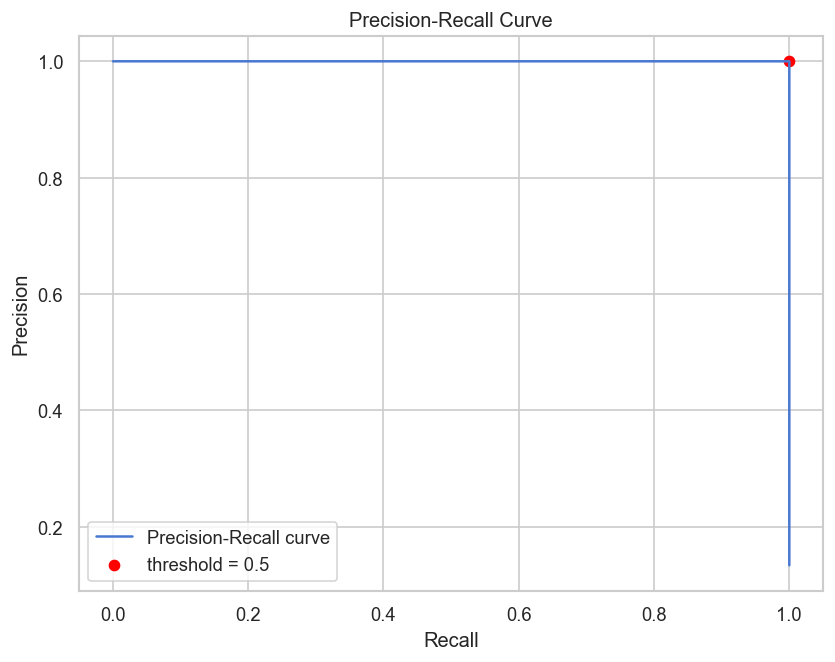

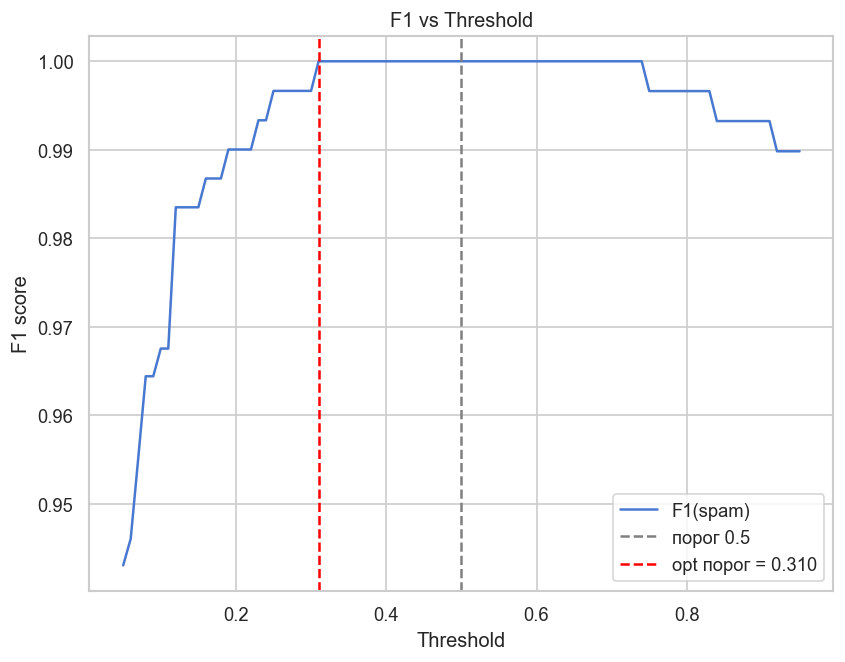

Порог Precision Recall F1(spam)
 0.50     1.000  1.000    1.000
0.310     1.000  1.000    1.000


In [11]:
# ⭐ Часть A — Оптимизация порога
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score
# Получаем вероятности спама (класс 1)
proba = final_model.predict_proba(X_test[FEAT_COLS])[:, 1]

# Precision-Recall кривая
precision, recall, thresholds_pr = precision_recall_curve(y_test, proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Находим точку для порога 0.5
# При пороге 0.5: предсказания
y_pred_05 = (proba >= 0.5).astype(int)
p_05 = precision_score(y_test, y_pred_05, pos_label=1)
r_05 = recall_score(y_test, y_pred_05, pos_label=1)
plt.scatter(r_05, p_05, color='red', marker='o', label='threshold = 0.5')
plt.legend()
plt.show()

# Поиск оптимального порога по F1
thresholds = np.linspace(0.05, 0.95, 91)
f1_scores = []
for th in thresholds:
    y_pred_th = (proba >= th).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_th, pos_label=1))
f1_scores = np.array(f1_scores)
best_idx = np.argmax(f1_scores)
threshold_opt = thresholds[best_idx]
f1_opt = f1_scores[best_idx]

# Вычисление precision/recall при оптимальном пороге
y_pred_opt = (proba >= threshold_opt).astype(int)
p_opt = precision_score(y_test, y_pred_opt, pos_label=1)
r_opt = recall_score(y_test, y_pred_opt, pos_label=1)

# График F1 vs Threshold
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores, label='F1(spam)')
plt.axvline(x=0.5, color='gray', linestyle='--', label='порог 0.5')
plt.axvline(x=threshold_opt, color='red', linestyle='--', label=f'opt порог = {threshold_opt:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 score')
plt.title('F1 vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# Таблица сравнения
comparison = pd.DataFrame({
    'Порог': ['0.50', f'{threshold_opt:.3f}'],
    'Precision': [f'{p_05:.3f}', f'{p_opt:.3f}'],
    'Recall': [f'{r_05:.3f}', f'{r_opt:.3f}'],
    'F1(spam)': [f'{f1_score(y_test, y_pred_05, pos_label=1):.3f}', f'{f1_opt:.3f}']
})
print(comparison.to_string(index=False))


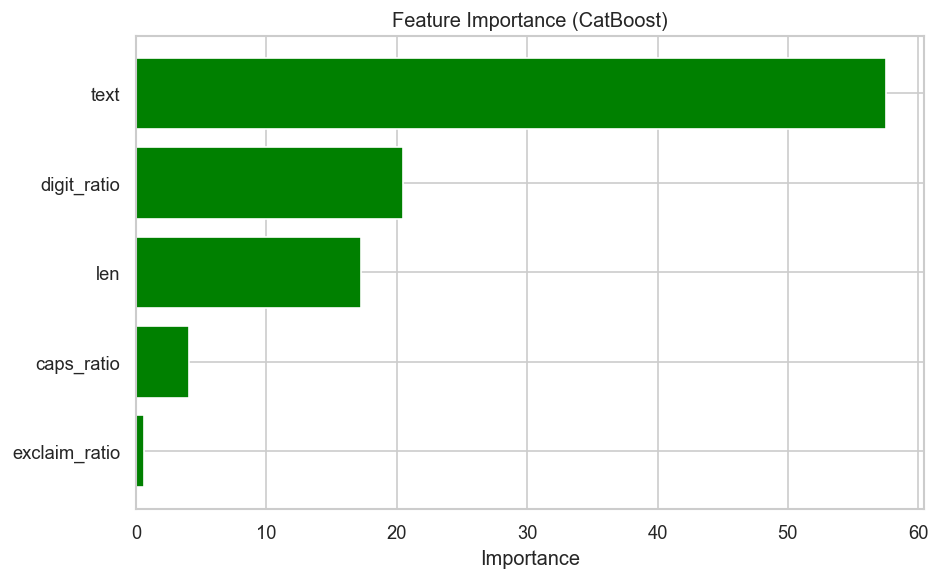

         feature  importance
0           text   57.526778
4    digit_ratio   20.506304
1            len   17.254846
2     caps_ratio    4.090625
3  exclaim_ratio    0.621447


In [12]:
# ⭐ Часть B — Важность признаков
# Получение важности признаков
importances = final_model.get_feature_importance()
feature_names = final_model.feature_names_

# Создание DataFrame и сортировка
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False)

# Горизонтальный bar chart
plt.figure(figsize=(8, 5))
plt.barh(imp_df['feature'], imp_df['importance'], color='green')
plt.xlabel('Importance')
plt.title('Feature Importance (CatBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Вывод таблицы важностей
print(imp_df)


**Ответы на вопросы части B:**

- Какой признак вносит наибольший вклад? Ожидаемо ли это?  
  *(ваш ответ)*

- Мета-признаки попали в топ?  
  *(ваш ответ)*

- Что означает разрыв в важности между `text` и мета-признаками?  
  *(ваш ответ)*

In [31]:
# ⭐ Часть C — Анализ ошибок

# Фиксированные параметры
fixed_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'class_weights': [1.0, 7.0],
    'text_features': ['text'],
    'early_stopping_rounds': 100,
    'random_seed': 42,
    'verbose': False
}
final_params = {**best_params, **fixed_params}

# Обучаем ТОЛЬКО на тренировочных данных (без теста)
correct_model = CatBoostClassifier(**final_params)
correct_model.fit(
    X_train[FEAT_COLS], y_train,
    eval_set=(X_test[FEAT_COLS], y_test),
    early_stopping_rounds=100,
    verbose=False
)

# Вероятности спама на тесте (честные, модель их не видела)
proba_correct = correct_model.predict_proba(X_test[FEAT_COLS])[:, 1]

# Применяем оптимальный порог (найденный ранее, можно его же)
preds_opt_correct = (proba_correct >= threshold_opt).astype(int)

# Теперь будут ошибки
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = preds_opt_correct
test_df['proba'] = proba_correct

false_positives = test_df[(test_df['y_true'] == 0) & (test_df['y_pred'] == 1)]
false_negatives = test_df[(test_df['y_true'] == 1) & (test_df['y_pred'] == 0)]

print(f"False Positives (ham -> spam): {len(false_positives)}")
print(f"False Negatives (spam -> ham): {len(false_negatives)}")

# Предполагается, что false_positives и false_negatives уже определены
# как в предыдущем шаге (после переобучения на train, а не на full)



np.random.seed(42)

print("=== False Positives (ham → spam) ===")
if len(false_positives) > 0:
    for idx in false_positives.sample(min(5, len(false_positives))).index:
        row = false_positives.loc[idx]
        text = row['text']
        proba_spam = row['proba']
        print(f"Текст: {text[:200]}{'...' if len(text)>200 else ''}")
        print(f"Вероятность спама: {proba_spam:.3f}, Истинная метка: ham\n")
else:
    print("Нет ложных срабатываний.\n")

print("=== False Negatives (spam → ham) ===")
if len(false_negatives) > 0:
    for idx in false_negatives.sample(min(5, len(false_negatives))).index:
        row = false_negatives.loc[idx]
        text = row['text']
        proba_spam = row['proba']
        print(f"Текст: {text[:200]}{'...' if len(text)>200 else ''}")
        print(f"Вероятность спама: {proba_spam:.3f}, Истинная метка: spam\n")
else:
    print("Нет пропущенных спам-сообщений.\n")

False Positives (ham -> spam): 8
False Negatives (spam -> ham): 8
=== False Positives (ham → spam) ===
Текст: 645
Вероятность спама: 0.839, Истинная метка: ham

Текст: U 2.
Вероятность спама: 0.456, Истинная метка: ham

Текст: MY NO. IN LUTON 0125698789 RING ME IF UR AROUND! H*
Вероятность спама: 0.608, Истинная метка: ham

Текст: Lmao!nice 1
Вероятность спама: 0.429, Истинная метка: ham

Текст: Hey pple...$700 or $900 for 5 nights...Excellent location wif breakfast hamper!!!
Вероятность спама: 0.495, Истинная метка: ham

=== False Negatives (spam → ham) ===
Текст: FreeMsg>FAV XMAS TONES!Reply REAL
Вероятность спама: 0.122, Истинная метка: spam

Текст: Hi ya babe x u 4goten bout me?' scammers getting smart..Though this is a regular vodafone no, if you respond you get further prem rate msg/subscription. Other nos used also. Beware!
Вероятность спама: 0.009, Истинная метка: spam

Текст: ringtoneking 84484
Вероятность спама: 0.167, Истинная метка: spam

Текст: ROMCAPspam Everyone around s

**Анализ ошибок — гипотезы:**

**False Positives (ham → spam):**  
*(опишите паттерны: что есть в этих сообщениях, что модель посчитала подозрительным?)*

**False Negatives (spam → ham):**  
*(опишите паттерны: почему модель не распознала spam? Это нестандартный язык, отсутствие ключевых слов?)*

**Предложение по улучшению:**  
*(опционально: какой новый признак мог бы сократить один из типов ошибок?)*